# Exploratory Data Analysis

## Imports

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

## Loading Dataset

In [2]:
file_names = ['Friday-02-03-2018_TrafficForML_CICFlowMeter.csv', 'Friday-16-02-2018_TrafficForML_CICFlowMeter.csv', 'Friday-23-02-2018_TrafficForML_CICFlowMeter.csv', 'Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv', 'Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv', 'Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv', 'Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv', 'Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv', 'Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv', 'Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv'
              ]

raw_dataset_dir = Path('../dataset/raw')


In [3]:
current_dataset_file_idx = 0
df = pd.read_csv(Path(raw_dataset_dir, file_names[current_dataset_file_idx]))

It was observed that some CSVs have  trouble loading, when we try loading  them, we encounter mixed types error when `low_memory` is set to `True`, setting this to `False` removes the warning, but makes most of the columns `str`.

This was observed in files:

1. Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
2. Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv
3. Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv

Further  investigations regarding this issue shall be done in a separate notebook.

## Analysis

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  str    
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  float64
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-null  float6

In [5]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)


In [6]:
pd.set_option("display.float_format", "{:.2f}".format)
df.max(numeric_only=True)
print(df.describe())

        Dst Port   Protocol  Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  \
count 1044525.00 1044525.00     1044525.00    1044525.00    1044525.00   
mean     8266.77       8.06    11558853.46          5.90          7.01   
std     14962.31       4.44    30170920.50         89.21        213.37   
min         0.00       0.00           1.00          1.00          0.00   
25%        80.00       6.00         519.00          2.00          0.00   
50%      3389.00       6.00       11274.00          3.00          1.00   
75%      8080.00       6.00     2221014.00          7.00          5.00   
max     65534.00      17.00   119999997.00      43159.00      69241.00   

       TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  Fwd Pkt Len Min  \
count       1044525.00       1044525.00       1044525.00       1044525.00   
mean            393.55          5291.71           211.20             8.27   
std            2163.83        309474.89           267.18            20.98   
min               0.00   

In [7]:
negative_counts = (df.select_dtypes(include="number") < 0).sum()
negative_counts[negative_counts > 0]

Init Fwd Win Byts    216083
Init Bwd Win Byts    510550
dtype: int64

In [8]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        print(col, df[df[col] < 0][col].unique())

Dst Port []
Protocol []
Flow Duration []
Tot Fwd Pkts []
Tot Bwd Pkts []
TotLen Fwd Pkts []
TotLen Bwd Pkts []
Fwd Pkt Len Max []
Fwd Pkt Len Min []
Fwd Pkt Len Mean []
Fwd Pkt Len Std []
Bwd Pkt Len Max []
Bwd Pkt Len Min []
Bwd Pkt Len Mean []
Bwd Pkt Len Std []
Flow Byts/s []
Flow Pkts/s []
Flow IAT Mean []
Flow IAT Std []
Flow IAT Max []
Flow IAT Min []
Fwd IAT Tot []
Fwd IAT Mean []
Fwd IAT Std []
Fwd IAT Max []
Fwd IAT Min []
Bwd IAT Tot []
Bwd IAT Mean []
Bwd IAT Std []
Bwd IAT Max []
Bwd IAT Min []
Fwd PSH Flags []
Bwd PSH Flags []
Fwd URG Flags []
Bwd URG Flags []
Fwd Header Len []
Bwd Header Len []
Fwd Pkts/s []
Bwd Pkts/s []
Pkt Len Min []
Pkt Len Max []
Pkt Len Mean []
Pkt Len Std []
Pkt Len Var []
FIN Flag Cnt []
SYN Flag Cnt []
RST Flag Cnt []
PSH Flag Cnt []
ACK Flag Cnt []
URG Flag Cnt []
CWE Flag Count []
ECE Flag Cnt []
Down/Up Ratio []
Pkt Size Avg []
Fwd Seg Size Avg []
Bwd Seg Size Avg []
Fwd Byts/b Avg []
Fwd Pkts/b Avg []
Fwd Blk Rate Avg []
Bwd Byts/b Avg []
Bwd

From the above it looks like the dataset  is already partially preprocessed and cleaned. We're only observing negative values in the following columns:

1. Init Fwd Win Byts
2. Init Bwd Win Byts

And the values are all -1, which is a semantic value, which means that this flow is not TCP and the TCP specific window size is hence not-applicable to this flow.

This has been observed for files:

1. Friday-02-03-2018_TrafficForML_CICFlowMeter.csv

In [9]:
df.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

The above columns are semantically matching with columns of CICIDS2017, with the following  columns being addition over CICIDS2017:

1. Protocol
2. Timestamp

The only difference is how columns are named.

So by renaming the columns, and some minor tweaks done to  handle this two columns. We can use the CICIDS2017 preprocessing pipeline to handle the `preprocessing stage #1: Cleaning`. This has currently only been tested in one file of CICIDS2018, but I doubt that there would be that much of a difference between various CSVs. Needs investigation.

Files investigated:

1. Friday-02-03-2018_TrafficForML_CICFlowMeter.csv

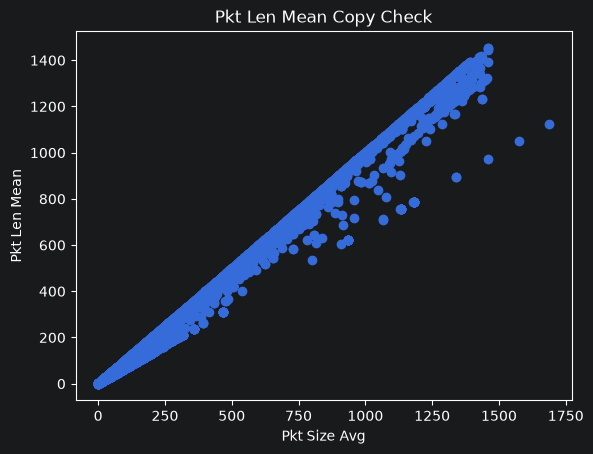

In [10]:
plt_path = Path('../images',  file_names[current_dataset_file_idx])
plt_path.mkdir(parents=True, exist_ok=True)

plt.scatter(df['Pkt Size Avg'], df['Pkt Len Mean'])
plt.title("Pkt Len Mean Copy Check")
plt.xlabel("Pkt Size Avg")
plt.ylabel("Pkt Len Mean")
plt.savefig(Path(plt_path,'Pkt Len Mean Copy Check.png'))
plt.show()

Based on column names, it was expected that `Pkt Size Avg` and `Pkt Len Mean` would be same or equivalent. However, its observed that they aren't. This observation holds true for:

1. Friday-02-03-2018_TrafficForML_CICFlowMeter.csv

In [11]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64'] and df[col].var() == 0:
        print(col, end=" ")
        print(df[col].unique())

Bwd PSH Flags [0]
Fwd URG Flags [0]
Bwd URG Flags [0]
CWE Flag Count [0]
Fwd Byts/b Avg [0]
Fwd Pkts/b Avg [0]
Fwd Blk Rate Avg [0]
Bwd Byts/b Avg [0]
Bwd Pkts/b Avg [0]
Bwd Blk Rate Avg [0]


The following columns had zero variance and their values were  found to  be zero:

1. Bwd PSH Flags
2. Fwd URG Flags
3. Bwd URG Flags
4. CWE Flag Count
5. Fwd Byts/b Avg
6. Fwd Pkts/b Avg
7. Fwd Blk Rate Avg
8. Bwd Byts/b Avg
9. Bwd Pkts/b Avg
10. Bwd Blk Rate Avg

This was observed for files:

1. Friday-02-03-2018_TrafficForML_CICFlowMeter.csv

If this same observation is made across all 10 CSVs, these columns would be removed / dropped.

In [12]:
corr = df.corr(numeric_only=True)
out_data_path = Path('../out/data', file_names[current_dataset_file_idx])
out_data_path.mkdir(exist_ok=True, parents=True)
corr.to_csv(Path(out_data_path, 'corr.csv'))
corr

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Dst Port,1.00,-0.25,-0.01,-0.02,-0.01,-0.05,-0.01,-0.22,-0.19,-0.25,...,-0.05,0.27,-0.02,-0.03,-0.03,-0.02,0.16,-0.02,0.16,0.17
Protocol,-0.25,1.00,-0.21,-0.02,-0.01,-0.07,-0.01,-0.29,0.77,-0.09,...,-0.05,-0.82,-0.07,-0.06,-0.08,-0.05,-0.15,-0.03,-0.15,-0.15
Flow Duration,-0.01,-0.21,1.00,0.07,0.05,0.08,0.04,0.06,-0.13,-0.10,...,0.13,0.03,0.15,0.15,0.19,0.11,0.73,0.18,0.73,0.72
Tot Fwd Pkts,-0.02,-0.02,0.07,1.00,0.64,0.11,0.63,0.05,-0.02,0.01,...,0.19,0.02,0.04,0.04,0.06,0.03,0.02,0.03,0.02,0.01
Tot Bwd Pkts,-0.01,-0.01,0.05,0.64,1.00,0.08,1.00,0.03,-0.01,0.00,...,0.13,0.01,0.02,0.02,0.03,0.02,0.01,0.03,0.02,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Active Min,-0.02,-0.05,0.11,0.03,0.02,0.02,0.02,-0.00,-0.02,-0.01,...,0.01,-0.07,0.91,0.15,0.73,1.00,0.04,0.09,0.04,0.03
Idle Mean,0.16,-0.15,0.73,0.02,0.01,0.01,0.01,-0.09,-0.09,-0.15,...,0.02,0.02,0.04,0.03,0.05,0.04,1.00,0.10,1.00,1.00
Idle Std,-0.02,-0.03,0.18,0.03,0.03,0.03,0.02,0.02,-0.02,0.00,...,0.04,-0.00,0.14,0.16,0.17,0.09,0.10,1.00,0.17,0.04
Idle Max,0.16,-0.15,0.73,0.02,0.02,0.01,0.01,-0.08,-0.09,-0.15,...,0.02,0.02,0.05,0.04,0.06,0.04,1.00,0.17,1.00,0.99


## Perfect Positive Correlation (r = +1.000)

| Feature 1        | Feature 2        | Correlation |
|------------------|------------------|------------:|
| Tot Fwd Pkts     | Subflow Fwd Pkts |   +1.000000 |
| Tot Bwd Pkts     | Subflow Bwd Pkts |   +1.000000 |
| TotLen Fwd Pkts  | Subflow Fwd Byts |   +1.000000 |
| Fwd Pkt Len Mean | Fwd Seg Size Avg |   +1.000000 |
| Bwd Pkt Len Mean | Bwd Seg Size Avg |   +1.000000 |
| Fwd PSH Flags    | SYN Flag Cnt     |   +1.000000 |

## Very High Positive Correlation (0.95 ≤ r < 1.00)

| Feature 1        | Feature 2        | Correlation |
|------------------|------------------|------------:|
| TotLen Bwd Pkts  | Subflow Bwd Byts |   +0.999999 |
| RST Flag Cnt     | ECE Flag Cnt     |   +0.999998 |
| Tot Bwd Pkts     | Subflow Bwd Byts |   +0.998868 |
| Subflow Bwd Pkts | Subflow Bwd Byts |   +0.998868 |
| Tot Bwd Pkts     | TotLen Bwd Pkts  |   +0.998864 |
| TotLen Bwd Pkts  | Subflow Bwd Pkts |   +0.998864 |
| Bwd Header Len   | Subflow Bwd Byts |   +0.998124 |
| TotLen Bwd Pkts  | Bwd Header Len   |   +0.998124 |
| Tot Bwd Pkts     | Bwd Header Len   |   +0.998095 |
| Bwd Header Len   | Subflow Bwd Pkts |   +0.998095 |
| Idle Mean        | Idle Min         |   +0.997832 |
| Idle Mean        | Idle Max         |   +0.997668 |
| Flow IAT Mean    | Flow IAT Min     |   +0.996028 |
| Flow Duration    | Fwd IAT Tot      |   +0.995104 |
| Flow IAT Mean    | Fwd IAT Mean     |   +0.995022 |
| Flow IAT Mean    | Fwd IAT Min      |   +0.994585 |
| Pkt Len Mean     | Pkt Size Avg     |   +0.994527 |
| Flow IAT Min     | Fwd IAT Min      |   +0.994331 |
| Fwd IAT Mean     | Fwd IAT Min      |   +0.993997 |
| Idle Max         | Idle Min         |   +0.991355 |
| Flow IAT Max     | Fwd IAT Max      |   +0.989782 |
| Flow IAT Min     | Fwd IAT Mean     |   +0.988191 |
| Bwd Pkt Len Max  | Pkt Len Max      |   +0.985861 |
| Bwd Pkt Len Max  | Bwd Pkt Len Std  |   +0.979387 |
| Flow Pkts/s      | Fwd Pkts/s       |   +0.975212 |
| Bwd Pkt Len Std  | Pkt Len Max      |   +0.970766 |
| Pkt Len Max      | Pkt Len Std      |   +0.961911 |
| Pkt Len Mean     | Bwd Seg Size Avg |   +0.956552 |
| Bwd Pkt Len Mean | Pkt Len Mean     |   +0.956552 |
| Bwd Pkt Len Std  | Pkt Len Std      |   +0.953368 |
| Pkt Size Avg     | Bwd Seg Size Avg |   +0.951870 |
| Bwd Pkt Len Mean | Pkt Size Avg     |   +0.951870 |

## High Positive Correlation (0.90 ≤ r < 0.95)

| Feature 1        | Feature 2        | Correlation |
|------------------|------------------|------------:|
| Active Mean      | Active Max       |   +0.946670 |
| Bwd Pkt Len Max  | Pkt Len Std      |   +0.942126 |
| Tot Fwd Pkts     | Fwd Header Len   |   +0.940253 |
| Fwd Header Len   | Subflow Fwd Pkts |   +0.940253 |
| Fwd Pkt Len Max  | Fwd Pkt Len Std  |   +0.935670 |
| Bwd Pkt Len Mean | Pkt Len Var      |   +0.934882 |
| Pkt Len Var      | Bwd Seg Size Avg |   +0.934882 |
| Fwd Pkt Len Min  | Pkt Len Min      |   +0.924157 |
| Pkt Len Std      | Pkt Len Var      |   +0.922494 |
| Bwd IAT Std      | Bwd IAT Max      |   +0.908941 |
| Pkt Len Mean     | Pkt Len Var      |   +0.908304 |
| Active Mean      | Active Min       |   +0.907532 |
| Fwd IAT Mean     | Fwd IAT Max      |   +0.905596 |
| Flow IAT Max     | Idle Max         |   +0.905259 |
| Flow IAT Max     | Idle Mean        |   +0.903254 |
| Fwd IAT Max      | Idle Max         |   +0.900942 |

## High Negative Correlation

| Feature 1        | Feature 2        | Correlation |
|------------------|------------------|------------:|
| Protocol         | Fwd Seg Size Min |   -0.817247 |
| Bwd Pkt Len Min  | Fwd Seg Size Min |   -0.768048 |
| Pkt Len Min      | Fwd Seg Size Min |   -0.757278 |
| Fwd Pkt Len Min  | Fwd Seg Size Min |   -0.693518 |
| PSH Flag Cnt     | ACK Flag Cnt     |   -0.649324 |
| Fwd Pkt Len Mean | ACK Flag Cnt     |   -0.609267 |
| ACK Flag Cnt     | Fwd Seg Size Avg |   -0.609267 |

**Total feature pairs with |r| ≥ 0.90: 54**

## Observations

The correlation analysis shows substantial redundancy among CICIDS2018 features. The strongest positive correlations are concentrated around packet counts, packet lengths, flow timing, inter-arrival times, and idle-time statistics. Several features appear to represent the same underlying network characteristic through different measurements.

## Duplicate Features

| Original Feature | Duplicate Feature |
|------------------|-------------------|
| Tot Fwd Pkts     | Subflow Fwd Pkts  |
| Tot Bwd Pkts     | Subflow Bwd Pkts  |
| TotLen Fwd Pkts  | Subflow Fwd Byts  |
| Fwd Pkt Len Mean | Fwd Seg Size Avg  |
| Bwd Pkt Len Mean | Bwd Seg Size Avg  |

These pairs exhibit perfect correlation (r = 1.0) and should be investigated for exact row-wise duplication before feature selection.

## Equivalent or Highly Related Statistics

| Feature          | Equivalent / Related Feature |
|------------------|------------------------------|
| Pkt Len Mean     | Pkt Size Avg                 |
| Fwd Pkt Len Mean | Fwd Seg Size Avg             |
| Bwd Pkt Len Mean | Bwd Seg Size Avg             |
| Pkt Len Std      | Pkt Len Var                  |
| Idle Mean        | Idle Min / Idle Max          |

These features describe closely related statistical properties and may provide overlapping information.

## Suspicious Correlations

| Feature 1     | Feature 2    | Correlation |
|---------------|--------------|------------:|
| Fwd PSH Flags | SYN Flag Cnt |   +1.000000 |
| RST Flag Cnt  | ECE Flag Cnt |   +0.999998 |

The perfect correlation between `Fwd PSH Flags` and `SYN Flag Cnt`, and the near-perfect correlation between `RST Flag Cnt` and `ECE Flag Cnt`, are unusual because these features represent different TCP flags. They should be investigated against the raw CICIDS2018 data before being treated as legitimate feature redundancy.

The above observation holds true for the following files:

1. Friday-02-03-2018_TrafficForML_CICFlowMeter.csv